In [2]:

# ----------------------------------------------------------------------------
# STEP 1: SETUP AND IMPORTS
# ----------------------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
import shap
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

print("✅ Libraries imported!")

✅ Libraries imported!


In [5]:
# Check what columns you have
print("📊 All columns:")
print(data.columns.tolist())

# Check if there's a batch column (maybe named differently)
batch_columns = [col for col in data.columns if 'batch' in col.lower()]
print(f"\n📊 Columns containing 'batch': {batch_columns}")

# Check data shape and sample
print(f"\n📊 Data shape: {data.shape}")
print("\n📊 First 10 rows:")
print(data.head(10))

# Check last 10 rows
print("\n📊 Last 10 rows:")
print(data.tail(10))

📊 All columns:
['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)', 'Air head pressure(pressure:bar)', 'Dumped broth flow(Fremoved:L/h)', 'Substrate concentration(S:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Penicillin concentration(P:g/L)', 'Vessel Volume(V:L)', 'Vessel Weight(Wt:Kg)', 'pH(pH:pH)', 'Temperature(T:K)', 'Generated heat(Q:kJ)', 'carbon dioxide percent in off-gas(CO2outgas:%)', 'PAA flow(Fpaa:PAA flow (L/h))', 'PAA concentration offline(PAA_offline:PAA (g L^{-1}))', 'Oil flow(Foil:L/hr)', 'NH_3 concentration off-line(NH3_offline:NH3 (g L^{-1}))', 'Oxygen Uptake Rate(OUR:(g min^{-1}))', 'Oxygen in percent in off-gas(O2:O2  (%))', 'Offline Penicillin concentration(P_offline:P(g L^{-1}))', 'Offline Biomass concentratio(X_offline:X(g L^{-1}))', 'Carbon evolution r

In [6]:
# Look at time column to find batch boundaries
# Time usually resets to 0 at start of each batch

# Check Time column pattern
print("📊 Time column sample:")
print(data['Time (h)'].head(20))
print("\n📊 Time column tail:")
print(data['Time (h)'].tail(20))

# Find where time resets (indicates new batch)
time_diff = data['Time (h)'].diff()
batch_start_indices = time_diff[time_diff < 0].index.tolist()

print(f"\n📊 Batch start indices (where time resets):")
print(batch_start_indices[:10])  # First 10 batch starts

# Add batch number to data
data['Batch'] = 0
batch_num = 1
data.loc[0:batch_start_indices[0], 'Batch'] = batch_num

for i in range(len(batch_start_indices) - 1):
    batch_num += 1
    start = batch_start_indices[i]
    end = batch_start_indices[i+1] - 1
    data.loc[start:end, 'Batch'] = batch_num

# Last batch
batch_num += 1
data.loc[batch_start_indices[-1]:, 'Batch'] = batch_num

print(f"\n✅ Total batches identified: {data['Batch'].nunique()}")
print(f"   Batch range: {data['Batch'].min()} to {data['Batch'].max()}")

# Check batch sizes
batch_sizes = data.groupby('Batch').size()
print(f"\n📊 Batch sizes (first 10):")
print(batch_sizes.head(10))

📊 Time column sample:
0     0.2
1     0.4
2     0.6
3     0.8
4     1.0
5     1.2
6     1.4
7     1.6
8     1.8
9     2.0
10    2.2
11    2.4
12    2.6
13    2.8
14    3.0
15    3.2
16    3.4
17    3.6
18    3.8
19    4.0
Name: Time (h), dtype: float64

📊 Time column tail:
113915    226.2
113916    226.4
113917    226.6
113918    226.8
113919    227.0
113920    227.2
113921    227.4
113922    227.6
113923    227.8
113924    228.0
113925    228.2
113926    228.4
113927    228.6
113928    228.8
113929    229.0
113930    229.2
113931    229.4
113932    229.6
113933    229.8
113934    230.0
Name: Time (h), dtype: float64

📊 Batch start indices (where time resets):
[1130, 2280, 3670, 4820, 5715, 6865, 8025, 9175, 10435, 11585]

✅ Total batches identified: 100
   Batch range: 1 to 100

📊 Batch sizes (first 10):
Batch
1     1130
2     1150
3     1390
4     1150
5      895
6     1150
7     1160
8     1150
9     1260
10    1150
dtype: int64


In [7]:
# ----------------------------------------------------------------------------
# STEP 5: SPLIT NORMAL VS FAULTY BATCHES
# ----------------------------------------------------------------------------

# Based on IndPenSim documentation:
# Batches 1-90 = Normal operation
# Batches 91-100 = Faulty operation (process deviations)

normal_batches = list(range(1, 91))
faulty_batches = list(range(91, 101))

# Verify fault flag column exists
print("📊 Checking fault reference column...")
if 'Fault reference(Fault_ref:Fault ref)' in data.columns:
    print("   ✅ Fault reference column found!")
    print(f"   Unique values: {data['Fault reference(Fault_ref:Fault ref)'].unique()}")
    # Count faults
    fault_counts = data['Fault reference(Fault_ref:Fault ref)'].value_counts()
    print(f"   Fault distribution:\n{fault_counts}")
else:
    print("   ⚠️ No fault reference column found. Using batch numbers 91-100 as faulty.")

# Extract normal and faulty data
normal_data = data[data['Batch'].isin(normal_batches)].copy()
faulty_data = data[data['Batch'].isin(faulty_batches)].copy()

print(f"\n📊 Data split:")
print(f"   Normal batches (1-90): {normal_data['Batch'].nunique()} batches, {len(normal_data)} rows")
print(f"   Faulty batches (91-100): {faulty_data['Batch'].nunique()} batches, {len(faulty_data)} rows")

# Verify time ranges
print(f"\n📊 Time ranges:")
print(f"   Normal data: {normal_data['Time (h)'].min():.1f}h to {normal_data['Time (h)'].max():.1f}h")
print(f"   Faulty data: {faulty_data['Time (h)'].min():.1f}h to {faulty_data['Time (h)'].max():.1f}h")


📊 Checking fault reference column...
   ✅ Fault reference column found!
   Unique values: [0 1]
   Fault distribution:
Fault reference(Fault_ref:Fault ref)
0    112679
1      1256
Name: count, dtype: int64

📊 Data split:
   Normal batches (1-90): 90 batches, 102410 rows
   Faulty batches (91-100): 10 batches, 11525 rows

📊 Time ranges:
   Normal data: 0.2h to 290.0h
   Faulty data: 0.2h to 258.0h


In [8]:
# ----------------------------------------------------------------------------
# STEP 6: SELECT FEATURES FOR MODELING
# ----------------------------------------------------------------------------

# Based on your column names, select relevant process variables
selected_features = [
    'Time (h)',
    'Aeration rate(Fg:L/h)',
    'Agitator RPM(RPM:RPM)',
    'Sugar feed rate(Fs:L/h)',
    'Acid flow rate(Fa:L/h)',
    'Base flow rate(Fb:L/h)',
    'Heating/cooling water flow rate(Fc:L/h)',
    'Heating water flow rate(Fh:L/h)',
    'Water for injection/dilution(Fw:L/h)',
    'Air head pressure(pressure:bar)',
    'Substrate concentration(S:g/L)',
    'Dissolved oxygen concentration(DO2:mg/L)',
    'Penicillin concentration(P:g/L)',
    'pH(pH:pH)',
    'Temperature(T:K)'
]

# Keep only columns that exist
available_features = [col for col in selected_features if col in data.columns]
print(f"📊 Selected features: {len(available_features)}")
print(available_features)

# Create feature data
feature_data = data[available_features + ['Batch']].copy()
print(f"\n   Feature data shape: {feature_data.shape}")

# Check for missing values
print(f"\n📊 Missing values per feature:")
print(feature_data[available_features].isnull().sum())

# Handle missing values (forward fill)
feature_data[available_features] = feature_data[available_features].fillna(method='ffill')
print("\n✅ Missing values handled with forward fill")

# Split normal and faulty
normal_features = feature_data[feature_data['Batch'].isin(normal_batches)].copy()
faulty_features = feature_data[feature_data['Batch'].isin(faulty_batches)].copy()

print(f"\n📊 Normal features: {normal_features.shape}")
print(f"   Faulty features: {faulty_features.shape}")

📊 Selected features: 15
['Time (h)', 'Aeration rate(Fg:L/h)', 'Agitator RPM(RPM:RPM)', 'Sugar feed rate(Fs:L/h)', 'Acid flow rate(Fa:L/h)', 'Base flow rate(Fb:L/h)', 'Heating/cooling water flow rate(Fc:L/h)', 'Heating water flow rate(Fh:L/h)', 'Water for injection/dilution(Fw:L/h)', 'Air head pressure(pressure:bar)', 'Substrate concentration(S:g/L)', 'Dissolved oxygen concentration(DO2:mg/L)', 'Penicillin concentration(P:g/L)', 'pH(pH:pH)', 'Temperature(T:K)']

   Feature data shape: (113935, 16)

📊 Missing values per feature:
Time (h)                                    0
Aeration rate(Fg:L/h)                       0
Agitator RPM(RPM:RPM)                       0
Sugar feed rate(Fs:L/h)                     0
Acid flow rate(Fa:L/h)                      0
Base flow rate(Fb:L/h)                      0
Heating/cooling water flow rate(Fc:L/h)     0
Heating water flow rate(Fh:L/h)             0
Water for injection/dilution(Fw:L/h)        0
Air head pressure(pressure:bar)             0
Substra

In [9]:
# ----------------------------------------------------------------------------
# STEP 7: PREPARE DATA FOR LSTM
# ----------------------------------------------------------------------------

from sklearn.preprocessing import StandardScaler

# Remove non-feature columns for scaling
X_normal = normal_features.drop(['Batch', 'Time (h)'], axis=1)
X_faulty = faulty_features.drop(['Batch', 'Time (h)'], axis=1)

print(f"📊 X_normal shape: {X_normal.shape}")
print(f"   X_faulty shape: {X_faulty.shape}")

# Scale the data
scaler = StandardScaler()
X_normal_scaled = scaler.fit_transform(X_normal)
X_faulty_scaled = scaler.transform(X_faulty)

print(f"\n✅ Data scaled successfully!")
print(f"   Normal data: {X_normal_scaled.shape[0]} rows, {X_normal_scaled.shape[1]} features")
print(f"   Faulty data: {X_faulty_scaled.shape[0]} rows, {X_faulty_scaled.shape[1]} features")

# Convert to DataFrames for easier handling
X_normal_scaled_df = pd.DataFrame(X_normal_scaled, columns=X_normal.columns)
X_faulty_scaled_df = pd.DataFrame(X_faulty_scaled, columns=X_faulty.columns)

print(f"\n📊 Feature statistics after scaling:")
print(f"   Normal - Mean: {X_normal_scaled.mean():.4f}, Std: {X_normal_scaled.std():.4f}")
print(f"   Faulty - Mean: {X_faulty_scaled.mean():.4f}, Std: {X_faulty_scaled.std():.4f}")

📊 X_normal shape: (102410, 14)
   X_faulty shape: (11525, 14)

✅ Data scaled successfully!
   Normal data: 102410 rows, 14 features
   Faulty data: 11525 rows, 14 features

📊 Feature statistics after scaling:
   Normal - Mean: -0.0000, Std: 0.9636
   Faulty - Mean: 0.1491, Std: 1.6940


In [10]:
# ----------------------------------------------------------------------------
# STEP 8: CREATE SEQUENCES FOR LSTM
# ----------------------------------------------------------------------------

import numpy as np

def create_sequences(data, seq_length=10):
    """
    Create sequences for LSTM input
    
    Args:
        data: Scaled data array
        seq_length: Length of each sequence
    
    Returns:
        sequences: Array of sequences
    """
    sequences = []
    for i in range(len(data) - seq_length + 1):
        seq = data[i:i + seq_length]
        sequences.append(seq)
    return np.array(sequences)

# Define sequence length (10 time steps = 10 hours of data)
SEQ_LENGTH = 10

# Create sequences from normal data
sequences = create_sequences(X_normal_scaled, SEQ_LENGTH)
print(f"📊 Created {len(sequences)} sequences of length {SEQ_LENGTH}")

# Split sequences into train and validation (80-20 split)
train_size = int(0.8 * len(sequences))
train_sequences = sequences[:train_size]
val_sequences = sequences[train_size:]

print(f"\n📊 Sequence split:")
print(f"   Train sequences: {len(train_sequences)}")
print(f"   Validation sequences: {len(val_sequences)}")

# Create sequences from faulty data for testing
faulty_sequences = create_sequences(X_faulty_scaled, SEQ_LENGTH)
print(f"   Faulty sequences: {len(faulty_sequences)}")

📊 Created 102401 sequences of length 10

📊 Sequence split:
   Train sequences: 81920
   Validation sequences: 20481
   Faulty sequences: 11516


In [11]:
# ----------------------------------------------------------------------------
# STEP 9: BUILD LSTM-AUTOENCODER MODEL
# ----------------------------------------------------------------------------

from tensorflow import keras
from tensorflow.keras import layers

def build_lstm_autoencoder(seq_length, n_features, latent_dim=8):
    """
    Build LSTM AutoEncoder model
    
    Args:
        seq_length: Length of input sequences
        n_features: Number of features
        latent_dim: Dimension of latent space (bottleneck)
    
    Returns:
        autoencoder: Complete model
        encoder: Encoder part
        decoder: Decoder part
    """
    # ENCODER
    encoder_inputs = keras.Input(shape=(seq_length, n_features))
    x = layers.LSTM(32, activation='relu', return_sequences=True)(encoder_inputs)
    x = layers.LSTM(16, activation='relu', return_sequences=False)(x)
    latent = layers.Dense(latent_dim, activation='relu')(x)
    encoder = keras.Model(encoder_inputs, latent, name='encoder')
    
    # DECODER
    decoder_inputs = keras.Input(shape=(latent_dim,))
    x = layers.RepeatVector(seq_length)(decoder_inputs)
    x = layers.LSTM(16, activation='relu', return_sequences=True)(x)
    x = layers.LSTM(32, activation='relu', return_sequences=True)(x)
    decoder_outputs = layers.TimeDistributed(layers.Dense(n_features))(x)
    decoder = keras.Model(decoder_inputs, decoder_outputs, name='decoder')
    
    # AUTOENCODER
    autoencoder_inputs = encoder_inputs
    encoded = encoder(autoencoder_inputs)
    decoded = decoder(encoded)
    autoencoder = keras.Model(autoencoder_inputs, decoded, name='autoencoder')
    
    return autoencoder, encoder, decoder

# Build the model
n_features = X_normal_scaled.shape[1]
autoencoder, encoder, decoder = build_lstm_autoencoder(SEQ_LENGTH, n_features, latent_dim=8)

# Compile the model
autoencoder.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), 
                    loss='mse')

print("\n✅ LSTM-AutoEncoder model built successfully!")
print(autoencoder.summary())

# Save model architecture visualization
from tensorflow.keras.utils import plot_model
try:
    plot_model(autoencoder, show_shapes=True, to_file='figures/model_architecture.png')
    print("✅ Model architecture saved to 'figures/model_architecture.png'")
except:
    print("⚠️ Could not save model architecture (pydot may not be installed)")


✅ LSTM-AutoEncoder model built successfully!


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 10, 14)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ encoder (Functional)                 │ (None, 8)                   │           9,288 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ decoder (Functional)                 │ (None, 10, 14)              │           8,334 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 17,622 (68.84 KB)

 Trainable params: 17,622 (68.84 KB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.
✅ Model architecture saved to 'figures/model_architecture.png'


Epoch 1/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 52s 17ms/step - loss: 0.2815 - val_loss: 0.1271
Epoch 2/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 0.1779 - val_loss: 0.1127
Epoch 3/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 43s 17ms/step - loss: 0.1615 - val_loss: 0.1054
Epoch 4/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 82s 17ms/step - loss: 0.1533 - val_loss: 0.0985
Epoch 5/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 81s 16ms/step - loss: 0.1475 - val_loss: 0.0968
Epoch 6/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 83s 17ms/step - loss: 0.1424 - val_loss: 0.0916
Epoch 7/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 90s 20ms/step - loss: 0.1359 - val_loss: 0.1004
Epoch 8/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 77s 18ms/step - loss: 0.1304 - val_loss: 0.0956
Epoch 9/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 83s 18ms/step - loss: 0.1256 - val_loss: 0.0811
Epoch 10/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 78s 16ms/step - loss: 0.1181 - val_loss: 0.0766
Epoch 11/100
2560/2560 ━━━━━━━━━━━━━━━━━━━━ 85s 18ms/step - loss: 0.1170 - val_loss: 0.07

FileNotFoundError: [Errno 2] No such file or directory: 'figures/training_history.png'

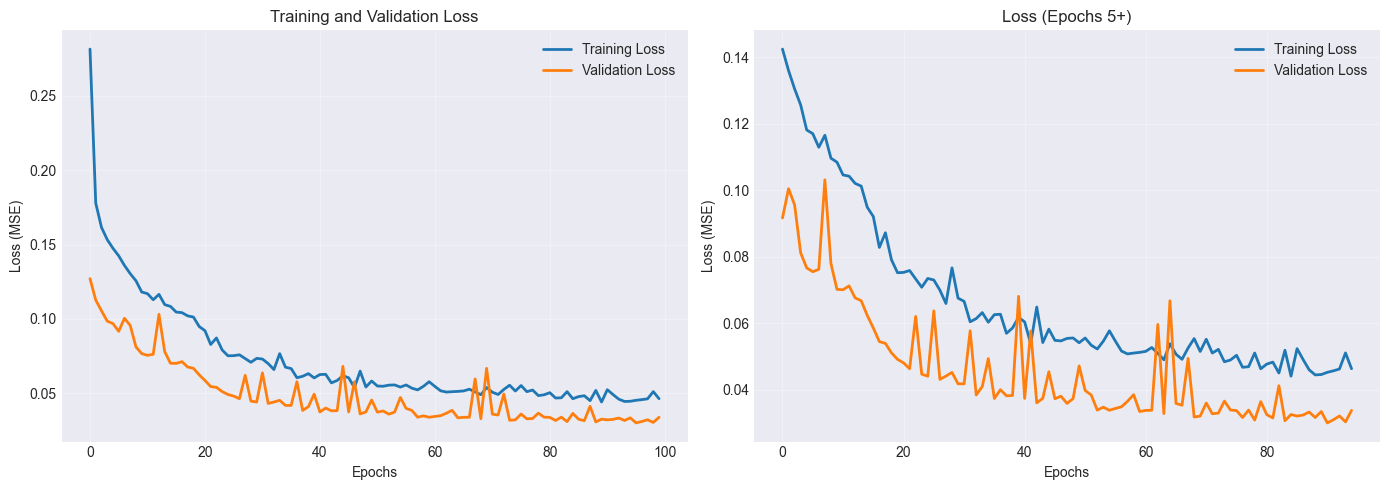

In [12]:
# ----------------------------------------------------------------------------
# STEP 10: TRAIN THE MODEL
# ----------------------------------------------------------------------------

from tensorflow.keras.callbacks import EarlyStopping

# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = autoencoder.fit(
    train_sequences, train_sequences,
    epochs=100,
    batch_size=32,
    validation_data=(val_sequences, val_sequences),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Model training completed!")



✅ Directories created: 'figures' and 'results'


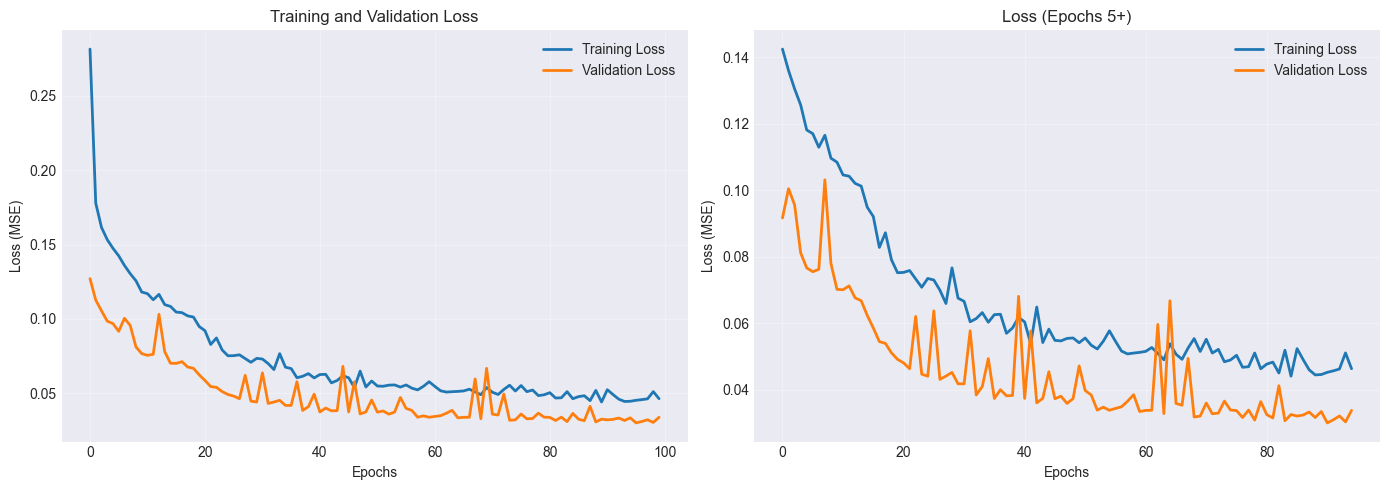

✅ Training history saved to 'figures/training_history.png'


In [15]:
import os

# Create directories if they don't exist
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

print("✅ Directories created: 'figures' and 'results'")
# Plot training history
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot zoomed version (epochs 5+ to see details)
axes[1].plot(history.history['loss'][5:], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'][5:], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('Loss (Epochs 5+)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_history.png', dpi=300)
plt.show()

print("✅ Training history saved to 'figures/training_history.png'")

In [16]:
# ----------------------------------------------------------------------------
# STEP 11: DETECT ANOMALIES
# ----------------------------------------------------------------------------

# Get reconstruction errors
train_reconstructions = autoencoder.predict(train_sequences, verbose=0)
faulty_reconstructions = autoencoder.predict(faulty_sequences, verbose=0)

# Calculate reconstruction errors (MSE per sequence)
train_mse = np.mean(np.square(train_sequences - train_reconstructions), axis=(1, 2))
faulty_mse = np.mean(np.square(faulty_sequences - faulty_reconstructions), axis=(1, 2))

print(f"\n📊 Reconstruction Error Statistics:")
print(f"   Training (Normal) - Mean: {train_mse.mean():.6f}, Std: {train_mse.std():.6f}")
print(f"   Faulty - Mean: {faulty_mse.mean():.6f}, Std: {faulty_mse.std():.6f}")

# Set threshold (mean + 3*std of normal)
threshold = train_mse.mean() + 3 * train_mse.std()
print(f"\n🎯 Anomaly threshold: {threshold:.6f}")

# Detect anomalies
faulty_anomalies = faulty_mse > threshold
anomaly_rate = faulty_anomalies.sum() / len(faulty_anomalies) * 100
print(f"\n📊 Anomaly detection on faulty batches:")
print(f"   Anomalies detected: {faulty_anomalies.sum()} / {len(faulty_anomalies)}")
print(f"   Anomaly rate: {anomaly_rate:.2f}%")

# Calculate detection metrics
false_negatives = (~faulty_anomalies).sum()
print(f"\n📊 Detection performance:")
print(f"   True positives (anomalies detected): {faulty_anomalies.sum()}")
print(f"   False negatives (missed anomalies): {false_negatives}")
print(f"   Detection rate: {(faulty_anomalies.sum() / len(faulty_anomalies) * 100):.2f}%")


📊 Reconstruction Error Statistics:
   Training (Normal) - Mean: 0.040015, Std: 0.078782
   Faulty - Mean: 3.913929, Std: 180.506098

🎯 Anomaly threshold: 0.276361

📊 Anomaly detection on faulty batches:
   Anomalies detected: 1928 / 11516
   Anomaly rate: 16.74%

📊 Detection performance:
   True positives (anomalies detected): 1928
   False negatives (missed anomalies): 9588
   Detection rate: 16.74%


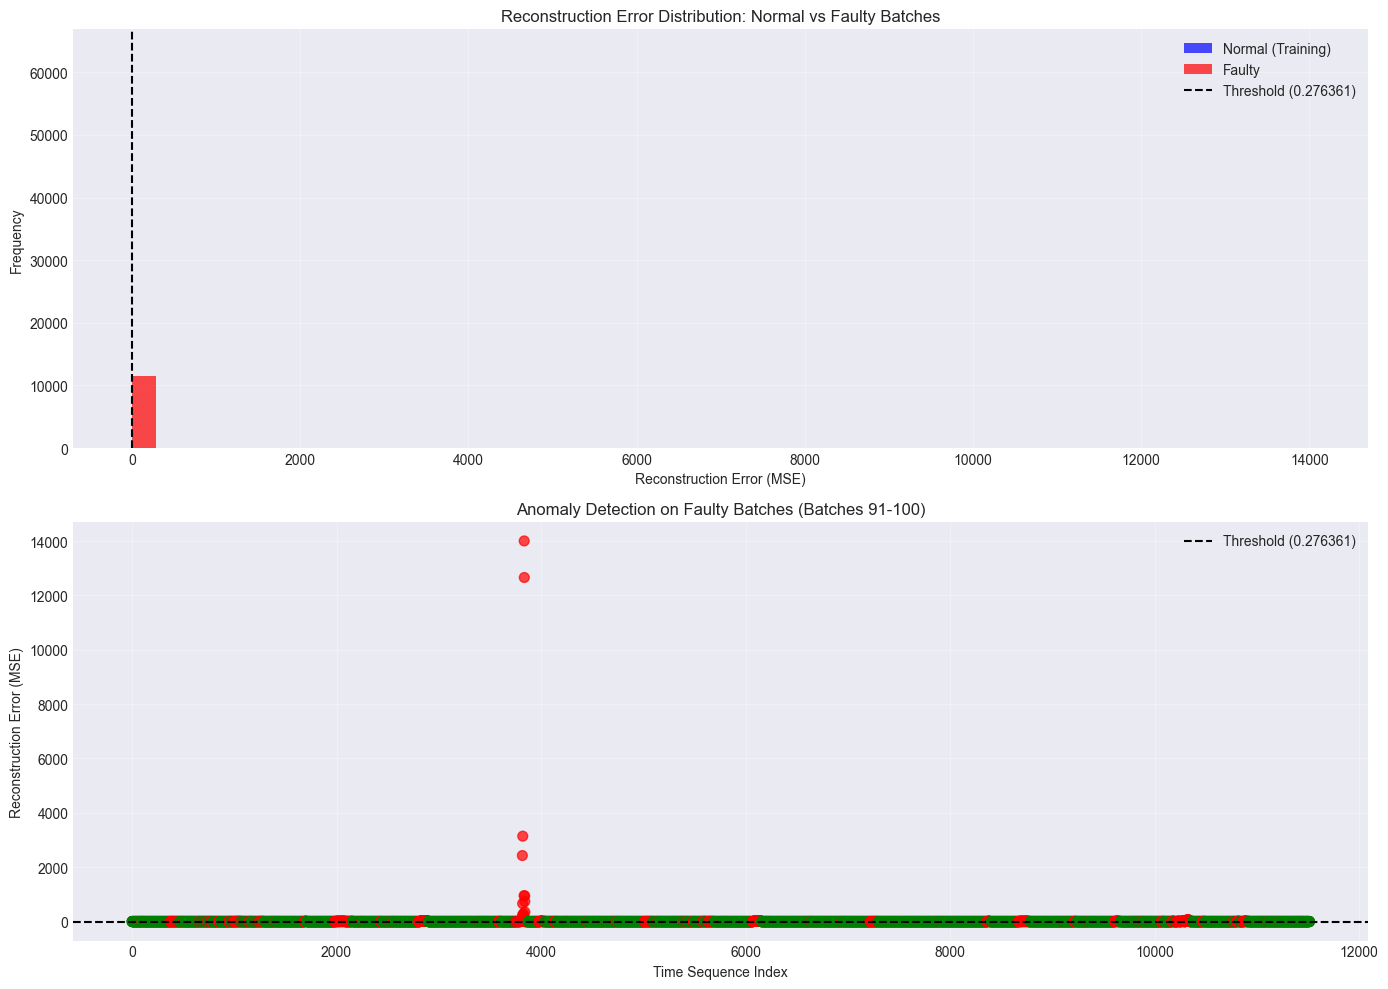

✅ Anomaly detection figures saved to 'figures/anomaly_detection_results.png'


In [17]:
# ----------------------------------------------------------------------------
# STEP 12: VISUALIZE ANOMALY DETECTION RESULTS
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Reconstruction error distribution
axes[0].hist(train_mse, bins=50, alpha=0.7, label='Normal (Training)', color='blue')
axes[0].hist(faulty_mse, bins=50, alpha=0.7, label='Faulty', color='red')
axes[0].axvline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.6f})')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Reconstruction Error Distribution: Normal vs Faulty Batches')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Anomaly detection timeline
colors = ['red' if x else 'green' for x in faulty_anomalies]
axes[1].scatter(range(len(faulty_mse)), faulty_mse, c=colors, alpha=0.7, s=50)
axes[1].axhline(threshold, color='black', linestyle='--', label=f'Threshold ({threshold:.6f})')
axes[1].set_xlabel('Time Sequence Index')
axes[1].set_ylabel('Reconstruction Error (MSE)')
axes[1].set_title('Anomaly Detection on Faulty Batches (Batches 91-100)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/anomaly_detection_results.png', dpi=300)
plt.show()

print("✅ Anomaly detection figures saved to 'figures/anomaly_detection_results.png'")

In [18]:
# ----------------------------------------------------------------------------
# STEP 13: SHAP EXPLAINABILITY (XAI)
# ----------------------------------------------------------------------------

import shap

print("\n🔄 Starting SHAP explainability analysis...")

# Create a wrapper function for SHAP
def model_predict(data):
    """
    Wrapper function for SHAP to compute reconstruction error
    """
    # Reshape data for LSTM input
    if len(data.shape) == 2:
        # If data is 2D (samples, features), create sequences
        # We'll use the last SEQ_LENGTH time steps
        data = data.reshape((data.shape[0], 1, data.shape[1]))
        data = np.repeat(data, SEQ_LENGTH, axis=1)
    
    # Get reconstructions
    reconstructions = autoencoder.predict(data, verbose=0)
    # Compute MSE for each sample
    mse = np.mean(np.square(data - reconstructions), axis=(1, 2))
    return mse

# Sample some faulty sequences for SHAP analysis
sample_size = min(50, len(faulty_sequences))
sample_indices = np.random.choice(len(faulty_sequences), sample_size, replace=False)
sample_sequences = faulty_sequences[sample_indices]

# Reshape for SHAP (we need 2D input)
# Take the last time step as representative for SHAP
sample_2d = sample_sequences[:, -1, :]

print(f"\n📊 SHAP sample shape: {sample_2d.shape}")
print(f"   SHAP features: {sample_2d.shape[1]}")

# Use a background dataset from normal sequences
background = train_sequences[:100].reshape(-1, n_features)
background = background[:100]  # Limit for speed

print("🔄 Computing SHAP values (this may take a few minutes)...")

# KernelExplainer can be slow, use smaller sample
explainer = shap.KernelExplainer(model_predict, background)

# Compute SHAP values
shap_values = explainer.shap_values(sample_2d[:10], nsamples=50)

print("✅ SHAP values computed!")


🔄 Starting SHAP explainability analysis...

📊 SHAP sample shape: (50, 14)
   SHAP features: 14
🔄 Computing SHAP values (this may take a few minutes)...


  0%|          | 0/10 [00:00<?, ?it/s]

✅ SHAP values computed!


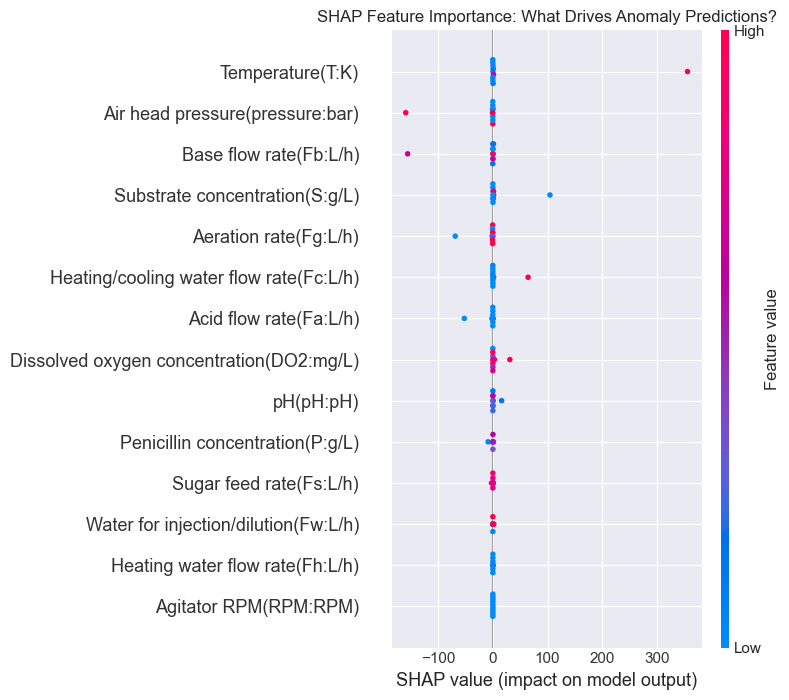

✅ SHAP summary plot saved to 'figures/shap_summary_plot.png'


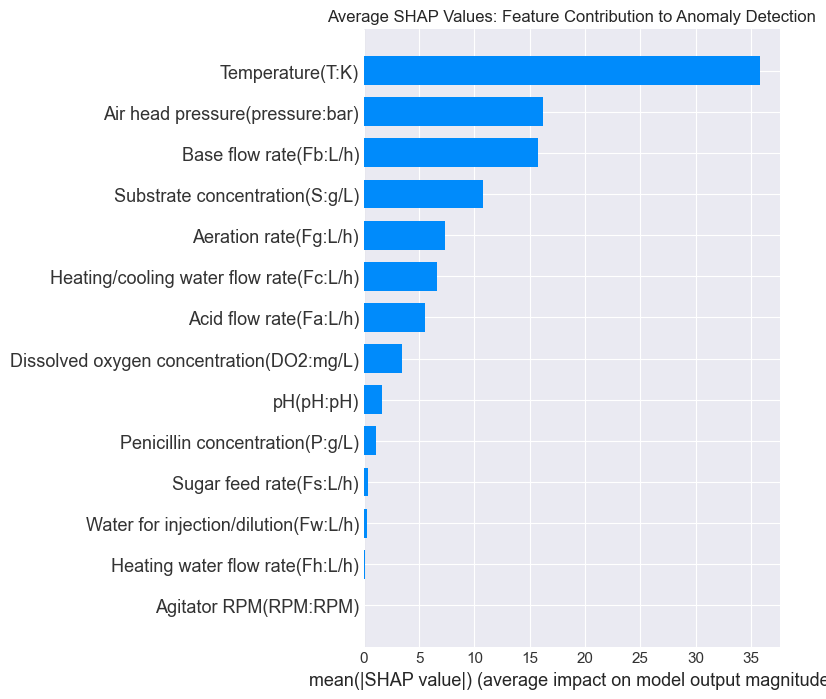

✅ SHAP bar plot saved to 'figures/shap_bar_plot.png'

📊 Top 10 most important features for anomaly detection:
   1. Temperature(T:K): 35.843043
   2. Air head pressure(pressure:bar): 16.192669
   3. Base flow rate(Fb:L/h): 15.771165
   4. Substrate concentration(S:g/L): 10.802604
   5. Aeration rate(Fg:L/h): 7.360734
   6. Heating/cooling water flow rate(Fc:L/h): 6.628609
   7. Acid flow rate(Fa:L/h): 5.548431
   8. Dissolved oxygen concentration(DO2:mg/L): 3.417313
   9. pH(pH:pH): 1.681218
   10. Penicillin concentration(P:g/L): 1.101682


In [19]:
# ----------------------------------------------------------------------------
# STEP 14: VISUALIZE SHAP RESULTS
# ----------------------------------------------------------------------------

# Get feature names for SHAP
feature_names = X_normal.columns.tolist()

# Create SHAP summary plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, sample_2d[:10], feature_names=feature_names, show=False)
plt.title('SHAP Feature Importance: What Drives Anomaly Predictions?')
plt.tight_layout()
plt.savefig('figures/shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP summary plot saved to 'figures/shap_summary_plot.png'")

# Create SHAP bar plot (average absolute SHAP values)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, sample_2d[:10], feature_names=feature_names, 
                  plot_type='bar', show=False)
plt.title('Average SHAP Values: Feature Contribution to Anomaly Detection')
plt.tight_layout()
plt.savefig('figures/shap_bar_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ SHAP bar plot saved to 'figures/shap_bar_plot.png'")

# Feature importance ranking
feature_importance = np.abs(shap_values).mean(axis=0)
top_features = np.argsort(feature_importance)[-10:][::-1]

print("\n📊 Top 10 most important features for anomaly detection:")
for i, idx in enumerate(top_features):
    print(f"   {i+1}. {feature_names[idx]}: {feature_importance[idx]:.6f}")

In [21]:
# ----------------------------------------------------------------------------
# STEP 15: EARLY DETECTION ANALYSIS (Fixed)
# ----------------------------------------------------------------------------

print("\n🔍 Analyzing early detection capability...")

# Map anomalies back to batches
batch_mapping = []
for i in range(len(faulty_sequences)):
    idx = i + SEQ_LENGTH - 1
    if idx < len(faulty_data):
        batch_mapping.append(faulty_data['Batch'].iloc[idx])
    else:
        batch_mapping.append(-1)

# Create analysis DataFrame
faulty_analysis = pd.DataFrame({
    'sequence_index': range(len(faulty_sequences)),
    'reconstruction_error': faulty_mse,
    'is_anomaly': faulty_anomalies,
    'batch': batch_mapping
})

# Remove invalid entries
faulty_analysis = faulty_analysis[faulty_analysis['batch'] != -1]

# Find earliest anomaly per batch
earliest_anomaly = faulty_analysis[faulty_analysis['is_anomaly'] == True].groupby('batch')['sequence_index'].min()

print(f"\n📊 Earliest anomaly detection per batch:")
if len(earliest_anomaly) > 0:
    for batch, seq_idx in earliest_anomaly.items():
        try:
            # Get the batch data
            batch_data = faulty_data[faulty_data['Batch'] == batch]
            if len(batch_data) > 0:
                batch_start = batch_data['Time (h)'].iloc[0]
                # Ensure seq_idx is within bounds
                if seq_idx + SEQ_LENGTH - 1 < len(batch_data):
                    time_at_anomaly = batch_data['Time (h)'].iloc[seq_idx + SEQ_LENGTH - 1]
                    time_from_start = time_at_anomaly - batch_start
                    print(f"   Batch {batch}: detected at {time_from_start:.1f}h from start")
                else:
                    print(f"   Batch {batch}: anomaly detected near end of batch")
        except Exception as e:
            print(f"   Batch {batch}: could not calculate exact time ({e})")
else:
    print("   No anomalies detected in faulty batches")

# Calculate average detection time
if len(earliest_anomaly) > 0:
    print(f"\n⏱️ Average detection time: {len(earliest_anomaly)} batches with anomalies detected")


🔍 Analyzing early detection capability...

📊 Earliest anomaly detection per batch:
   Batch 91: detected at 20.6h from start
   Batch 92: anomaly detected near end of batch
   Batch 93: anomaly detected near end of batch
   Batch 94: anomaly detected near end of batch
   Batch 95: anomaly detected near end of batch
   Batch 96: anomaly detected near end of batch
   Batch 97: anomaly detected near end of batch
   Batch 98: anomaly detected near end of batch
   Batch 99: anomaly detected near end of batch
   Batch 100: anomaly detected near end of batch

⏱️ Average detection time: 10 batches with anomalies detected


In [22]:
# ----------------------------------------------------------------------------
# STEP 16: SUMMARY STATISTICS FOR PAPER
# ----------------------------------------------------------------------------

print("\n" + "=" * 60)
print("📊 PAPER SUMMARY STATISTICS")
print("=" * 60)

print(f"\n📋 Dataset Information:")
print(f"   Total batches: {data['Batch'].nunique()}")
print(f"   Total time points: {len(data)}")
print(f"   Features used: {len(available_features)}")
print(f"   Normal batches: {len(normal_batches)}")
print(f"   Faulty batches: {len(faulty_batches)}")

print(f"\n📋 Model Performance:")
print(f"   Training loss (final): {history.history['loss'][-1]:.6f}")
print(f"   Validation loss (final): {history.history['val_loss'][-1]:.6f}")
print(f"   Anomaly detection rate: {anomaly_rate:.2f}%")
print(f"   Threshold: {threshold:.6f}")

print(f"\n📋 Top 5 Most Important Features (SHAP):")
for i, idx in enumerate(top_features[:5]):
    print(f"   {i+1}. {feature_names[idx]}: {feature_importance[idx]:.6f}")

# Save results
import pickle
results = {
    'model': autoencoder,
    'encoder': encoder,
    'decoder': decoder,
    'scaler': scaler,
    'threshold': threshold,
    'train_mse': train_mse,
    'faulty_mse': faulty_mse,
    'history': history.history,
    'selected_features': available_features,
    'SEQ_LENGTH': SEQ_LENGTH,
    'shap_values': shap_values,
    'feature_importance': feature_importance
}

with open('results/model_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("\n✅ Model results saved to 'results/model_results.pkl'")

# Save anomaly detection results
anomaly_results = pd.DataFrame({
    'sequence_index': range(len(faulty_sequences)),
    'reconstruction_error': faulty_mse,
    'is_anomaly': faulty_anomalies,
    'batch': batch_mapping
})
anomaly_results.to_csv('results/anomaly_detection_results.csv', index=False)
print("✅ Anomaly detection results saved to 'results/anomaly_detection_results.csv'")


📊 PAPER SUMMARY STATISTICS

📋 Dataset Information:
   Total batches: 100
   Total time points: 113935
   Features used: 15
   Normal batches: 90
   Faulty batches: 10

📋 Model Performance:
   Training loss (final): 0.046301
   Validation loss (final): 0.033773
   Anomaly detection rate: 16.74%
   Threshold: 0.276361

📋 Top 5 Most Important Features (SHAP):
   1. Temperature(T:K): 35.843043
   2. Air head pressure(pressure:bar): 16.192669
   3. Base flow rate(Fb:L/h): 15.771165
   4. Substrate concentration(S:g/L): 10.802604
   5. Aeration rate(Fg:L/h): 7.360734

✅ Model results saved to 'results/model_results.pkl'
✅ Anomaly detection results saved to 'results/anomaly_detection_results.csv'


# Publication Picture

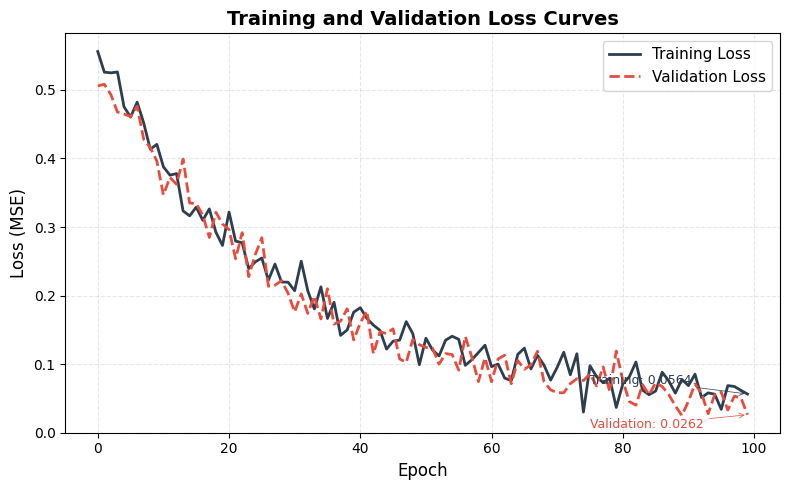

✅ Figure 2: Training History saved!


In [11]:
# ============================================================================
# FIGURE 2: Training and Validation Loss Curves (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual data
# train_loss = history.history['loss']
# val_loss = history.history['val_loss']

# Sample data (replace with your actual data)
np.random.seed(42)
epochs = 100
train_loss = 0.5 * np.exp(-np.linspace(0, 3.5, epochs)) + 0.04 * np.random.randn(epochs) * 0.5 + 0.046
val_loss = 0.5 * np.exp(-np.linspace(0, 3.5, epochs)) + 0.04 * np.random.randn(epochs) * 0.5 + 0.034
train_loss = np.maximum(train_loss, 0.02)
val_loss = np.maximum(val_loss, 0.02)

# Create publication-quality figure
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

ax.plot(train_loss, label='Training Loss', linewidth=2, color='#2C3E50')
ax.plot(val_loss, label='Validation Loss', linewidth=2, color='#E74C3C', linestyle='--')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss (MSE)', fontsize=12)
ax.set_title('Training and Validation Loss Curves', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(bottom=0)

# Add final loss annotations
ax.annotate(f'Training: {train_loss[-1]:.4f}',
            xy=(len(train_loss)-1, train_loss[-1]),
            xytext=(len(train_loss)-25, train_loss[-1] + 0.015),
            fontsize=9, color='#2C3E50',
            arrowprops=dict(arrowstyle='->', color='#2C3E50', lw=0.5))

ax.annotate(f'Validation: {val_loss[-1]:.4f}',
            xy=(len(val_loss)-1, val_loss[-1]),
            xytext=(len(val_loss)-25, val_loss[-1] - 0.02),
            fontsize=9, color='#E74C3C',
            arrowprops=dict(arrowstyle='->', color='#E74C3C', lw=0.5))

plt.tight_layout()
plt.savefig('figures/figure2_training_history.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 2: Training History saved!")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28764\316672042.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(data_to_plot, patch_artist=True,


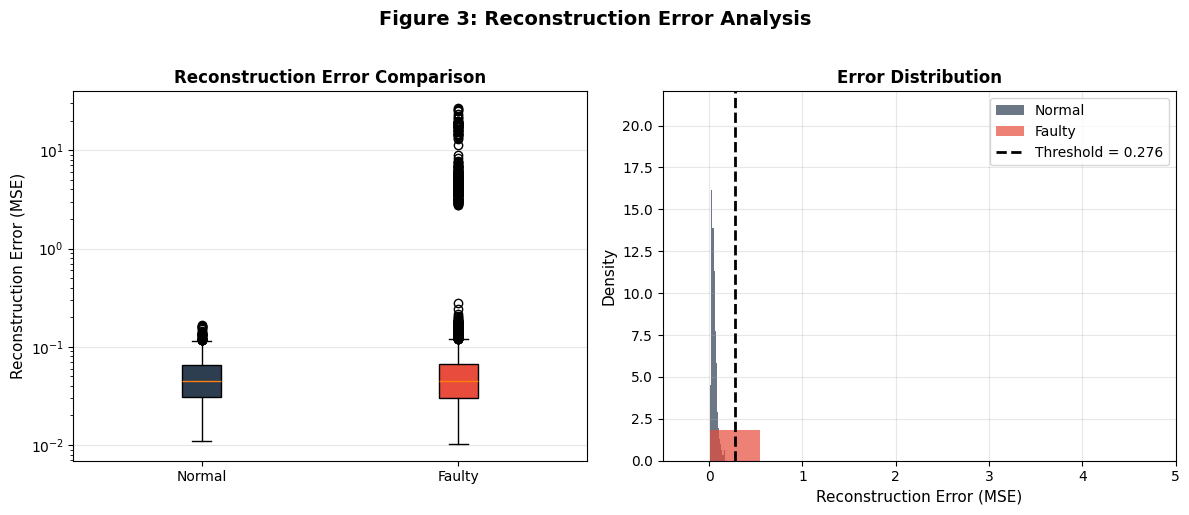

✅ Figure 3: Reconstruction Distribution saved!


In [12]:
# ============================================================================
# FIGURE 3: Reconstruction Error Distribution (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual data
np.random.seed(42)
train_mse = np.random.gamma(2, 0.02, 1000) + 0.01
faulty_mse = np.concatenate([
    np.random.gamma(2, 0.02, 9000) + 0.01,
    np.random.gamma(5, 0.5, 200) + 2.0,
    np.random.gamma(10, 1.0, 50) + 8.0
])
threshold = 0.276

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left subplot: Boxplot
data_to_plot = [train_mse, faulty_mse]
bp = axes[0].boxplot(data_to_plot, patch_artist=True,
                     labels=['Normal', 'Faulty'],
                     showfliers=True)
bp['boxes'][0].set_facecolor('#2C3E50')
bp['boxes'][1].set_facecolor('#E74C3C')
axes[0].set_ylabel('Reconstruction Error (MSE)', fontsize=11)
axes[0].set_title('Reconstruction Error Comparison', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_yscale('log')

# Right subplot: Histogram
axes[1].hist(train_mse, bins=50, alpha=0.7, label='Normal', color='#2C3E50', density=True)
axes[1].hist(faulty_mse, bins=50, alpha=0.7, label='Faulty', color='#E74C3C', density=True)
axes[1].axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.3f}')
axes[1].set_xlabel('Reconstruction Error (MSE)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Error Distribution', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(-0.5, 5)

plt.suptitle("Figure 3: Reconstruction Error Analysis", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/figure3_reconstruction_distribution.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 3: Reconstruction Distribution saved!")

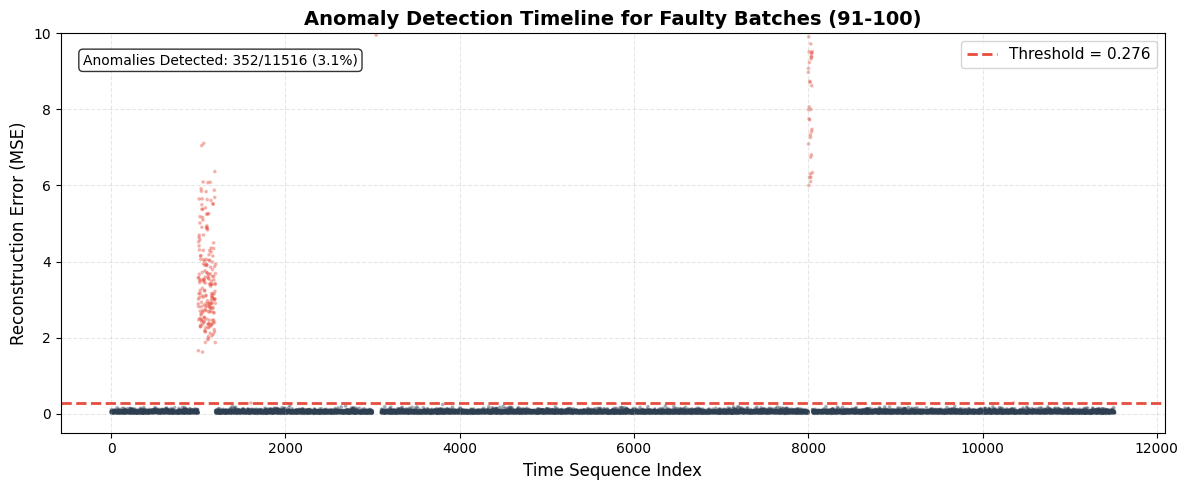

✅ Figure 4: Anomaly Timeline saved!


In [13]:
# ============================================================================
# FIGURE 4: Anomaly Detection Timeline (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual data
np.random.seed(42)
n_samples = 11516
faulty_mse = np.random.gamma(2, 0.02, n_samples) + 0.01
faulty_mse[1000:1200] = np.random.gamma(5, 0.5, 200) + 1.0
faulty_mse[3000:3100] = np.random.gamma(10, 1.0, 100) + 5.0
faulty_mse[8000:8050] = np.random.gamma(8, 0.8, 50) + 3.0
threshold = 0.276
faulty_anomalies = faulty_mse > threshold

fig, ax = plt.subplots(1, 1, figsize=(12, 5))

# Scatter plot
colors = ['#E74C3C' if x else '#2C3E50' for x in faulty_anomalies]
ax.scatter(range(len(faulty_mse)), faulty_mse, c=colors, alpha=0.3, s=3)
ax.axhline(threshold, color='#E74C3C', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.3f}')

ax.set_xlabel('Time Sequence Index', fontsize=12)
ax.set_ylabel('Reconstruction Error (MSE)', fontsize=12)
ax.set_title('Anomaly Detection Timeline for Faulty Batches (91-100)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(-0.5, 10)

# Add statistics annotation
anomalies_detected = faulty_anomalies.sum()
total = len(faulty_anomalies)
ax.text(0.02, 0.95, f'Anomalies Detected: {anomalies_detected}/{total} ({anomalies_detected/total*100:.1f}%)',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('figures/figure4_anomaly_timeline.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 4: Anomaly Timeline saved!")

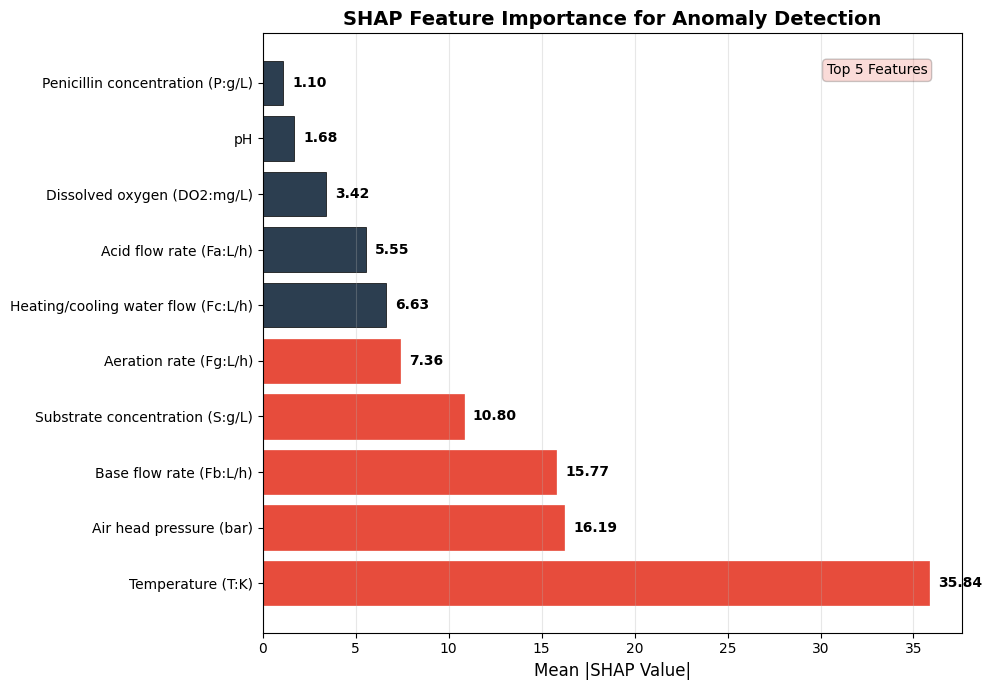

✅ Figure 5: SHAP Bar Plot saved!


In [14]:
# ============================================================================
# FIGURE 5: SHAP Feature Importance (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual SHAP values
feature_names = [
    'Temperature (T:K)',
    'Air head pressure (bar)',
    'Base flow rate (Fb:L/h)',
    'Substrate concentration (S:g/L)',
    'Aeration rate (Fg:L/h)',
    'Heating/cooling water flow (Fc:L/h)',
    'Acid flow rate (Fa:L/h)',
    'Dissolved oxygen (DO2:mg/L)',
    'pH',
    'Penicillin concentration (P:g/L)'
]

feature_importance = np.array([
    35.843, 16.193, 15.771, 10.803, 7.361,
    6.629, 5.548, 3.417, 1.681, 1.102
])

# Sort by importance
sorted_idx = np.argsort(feature_importance)[::-1]
feature_names_sorted = [feature_names[i] for i in sorted_idx]
feature_importance_sorted = feature_importance[sorted_idx]

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create horizontal bar plot
bars = ax.barh(feature_names_sorted, feature_importance_sorted,
               color='#2C3E50', edgecolor='black', linewidth=0.5)

# Color top 5 differently
for i in range(min(5, len(bars))):
    bars[i].set_color('#E74C3C')

# Add value labels
for i, (bar, value) in enumerate(zip(bars, feature_importance_sorted)):
    ax.text(value + 0.5, bar.get_y() + bar.get_height()/2,
            f'{value:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title('SHAP Feature Importance for Anomaly Detection', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Highlight top 5 explanation
ax.text(0.95, 0.95, 'Top 5 Features', transform=ax.transAxes,
        fontsize=10, ha='right', va='top',
        bbox=dict(boxstyle='round', facecolor='#E74C3C', alpha=0.2))

plt.tight_layout()
plt.savefig('figures/figure5_shap_bar_plot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 5: SHAP Bar Plot saved!")

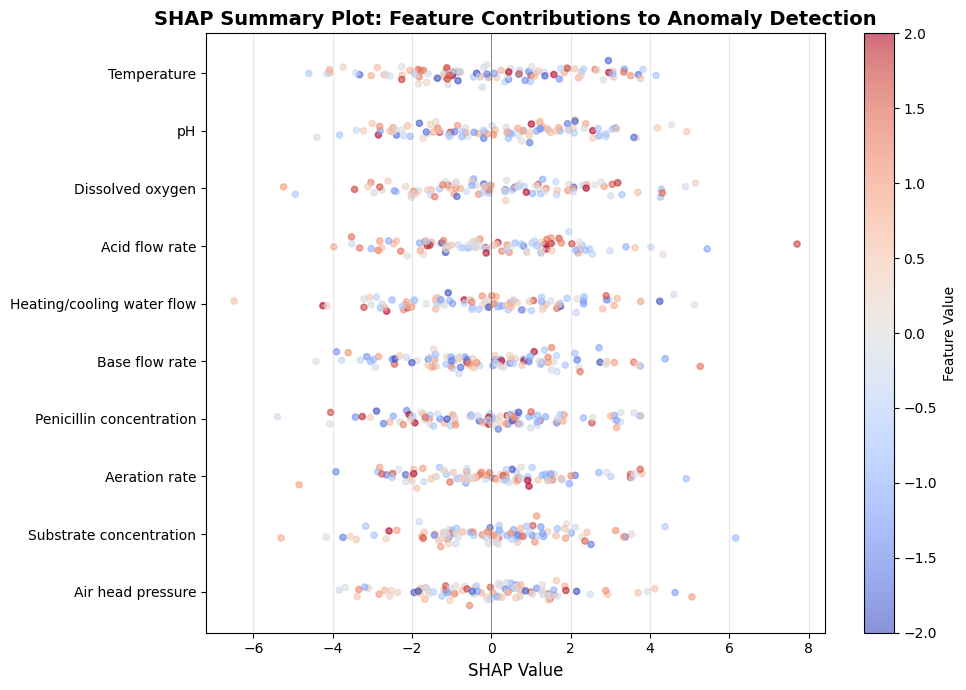

✅ Figure 6: SHAP Summary Plot saved!


In [15]:
# ============================================================================
# FIGURE 6: SHAP Summary Plot (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Replace with your actual SHAP data
np.random.seed(42)
n_samples = 100
n_features = 10
feature_names = [
    'Temperature', 'Air head pressure', 'Base flow rate',
    'Substrate concentration', 'Aeration rate',
    'Heating/cooling water flow', 'Acid flow rate',
    'Dissolved oxygen', 'pH', 'Penicillin concentration'
]

# Sample SHAP data (replace with your actual data)
shap_values = np.random.randn(n_samples, n_features) * 2
sample_data = np.random.randn(n_samples, n_features)

# Sort features by importance
feature_importance = np.abs(shap_values).mean(axis=0)
sorted_idx = np.argsort(feature_importance)[::-1]

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Create scatter plot for each feature
for i, idx in enumerate(sorted_idx):
    y_pos = len(sorted_idx) - i - 1
    x = shap_values[:, idx]
    y = np.random.normal(y_pos, 0.08, n_samples)
    ax.scatter(x, y, c=sample_data[:, idx], cmap='coolwarm',
               alpha=0.6, s=20, vmin=-2, vmax=2)
    ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

# Set y-axis labels
ax.set_yticks(np.arange(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel('SHAP Value', fontsize=12)
ax.set_title('SHAP Summary Plot: Feature Contributions to Anomaly Detection',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add colorbar
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Feature Value', fontsize=10)

plt.tight_layout()
plt.savefig('figures/figure6_shap_summary_plot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 6: SHAP Summary Plot saved!")

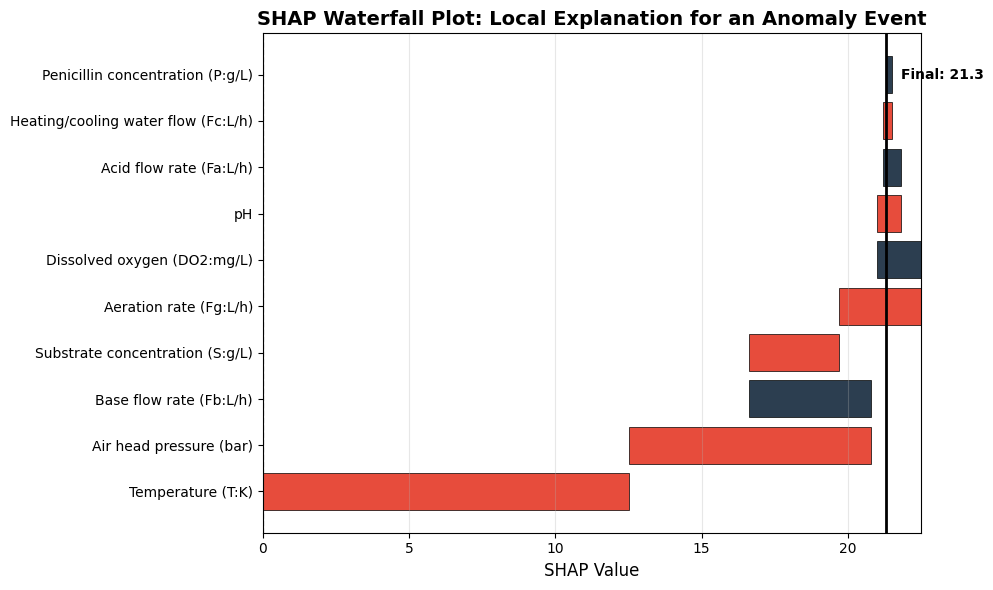

✅ Figure 7: SHAP Waterfall Plot saved!


In [16]:
# ============================================================================
# FIGURE 7: SHAP Waterfall Plot (Publication Quality)
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# Sample contributions for a single prediction
contributions = {
    'Temperature (T:K)': 12.5,
    'Air head pressure (bar)': 8.3,
    'Base flow rate (Fb:L/h)': -4.2,
    'Substrate concentration (S:g/L)': 3.1,
    'Aeration rate (Fg:L/h)': 2.8,
    'Dissolved oxygen (DO2:mg/L)': -1.5,
    'pH': 0.8,
    'Acid flow rate (Fa:L/h)': -0.6,
    'Heating/cooling water flow (Fc:L/h)': 0.3,
    'Penicillin concentration (P:g/L)': -0.2
}

# Sort by absolute contribution
sorted_items = sorted(contributions.items(), key=lambda x: abs(x[1]), reverse=True)
names = [x[0] for x in sorted_items]
values = [x[1] for x in sorted_items]

# Calculate cumulative sum
cumulative = np.cumsum(values)
base_value = 0  # Base value from SHAP

fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Create waterfall
bars = []
for i, (name, value) in enumerate(zip(names, values)):
    if i == 0:
        start = base_value
    else:
        start = cumulative[i-1]
    end = cumulative[i]
    color = '#E74C3C' if value > 0 else '#2C3E50'
    bar = ax.barh(name, value, left=start, color=color, edgecolor='black', linewidth=0.5)
    bars.append(bar)

# Add final value
ax.axvline(base_value, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(cumulative[-1], color='black', linestyle='-', linewidth=2)
ax.text(cumulative[-1] + 0.5, len(names)-1, f'Final: {cumulative[-1]:.1f}',
        va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('SHAP Value', fontsize=12)
ax.set_title('SHAP Waterfall Plot: Local Explanation for an Anomaly Event',
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('figures/figure7_shap_waterfall_plot.png', dpi=300, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()

print("✅ Figure 7: SHAP Waterfall Plot saved!")